In [2]:
import os
import sys

ROOT_PATH = '../../'
os.chdir(ROOT_PATH)

sys.path.append(os.path.abspath(ROOT_PATH))

lib_path = os.path.abspath(os.path.join(ROOT_PATH, 'lib'))
if lib_path not in sys.path:
  sys.path.append(lib_path)

In [3]:
from pathlib import Path

import torch
import numpy as np
import cv2
from tqdm.notebook import tqdm
import torch.nn.functional as F

from ai.lib.depth_anything_3.api import DepthAnything3

[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [5]:
da3 = DepthAnything3.from_pretrained("depth-anything/DA3-LARGE-1.1").to(device=device)
da3.eval()

ai.lib.depth_anything_3.model.da3
ai.lib.depth_anything_3.model.dinov2.dinov2
[INFO ] using MLP layer as FFN
ai.lib.depth_anything_3.model.dualdpt
ai.lib.depth_anything_3.model.cam_dec
ai.lib.depth_anything_3.model.cam_enc


DepthAnything3(
  (model): DepthAnything3Net(
    (backbone): DinoV2(
      (pretrained): DinoVisionTransformer(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
          (norm): Identity()
        )
        (rope): RotaryPositionEmbedding2D()
        (blocks): ModuleList(
          (0-7): 8 x Block(
            (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (attn): Attention(
              (qkv): Linear(in_features=1024, out_features=3072, bias=True)
              (q_norm): Identity()
              (k_norm): Identity()
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=1024, out_features=1024, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): LayerScale(1024, init_values=1.0, inplace=False)
            (drop_path1): Identity()
            (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)

In [6]:
normal_predictor = torch.hub.load("hugoycj/DSINE-hub", "DSINE", trust_repo=True)

Using cache found in C:\Users\ASUS/.cache\torch\hub\hugoycj_DSINE-hub_main


In [11]:
BASE_DATA_DIR = Path('./ai/data/RescueNet')
splits = ['train', 'val', 'test']
TARGET_IMAGE_SIZE = (640, 640)
DA3_INFERENCE_SIZE = (2016, 1512)

In [12]:
with torch.no_grad():
  for split in splits:
    org_dir = BASE_DATA_DIR / split / f"{split}-org-img"
    label_dir = BASE_DATA_DIR / split / f"{split}-label-img"
    labelnpy_dir = BASE_DATA_DIR / split / f"{split}-labelnpy-img"
    depth_dir = BASE_DATA_DIR / split / f"{split}-depth-img"
    depthvis_dir = BASE_DATA_DIR / split / f"{split}-depthvis-img"
    resized_org_dir = BASE_DATA_DIR / split / f"{split}-resized-img"
    
    # --- NEW: Normal Directories ---
    normal_dir = BASE_DATA_DIR / split / f"{split}-normal-img"
    normalvis_dir = BASE_DATA_DIR / split / f"{split}-normalvis-img"
    
    print(org_dir)
    print(org_dir.exists())
    
    resized_org_dir.mkdir(parents=True, exist_ok=True)
    labelnpy_dir.mkdir(parents=True, exist_ok=True)
    
    depth_dir.mkdir(parents=True, exist_ok=True)
    depthvis_dir.mkdir(parents=True, exist_ok=True)
    
    # --- NEW: Create Normal Directories ---
    normal_dir.mkdir(parents=True, exist_ok=True)
    normalvis_dir.mkdir(parents=True, exist_ok=True)
    
    all_label_paths = list(label_dir.glob('*.png'))
    all_image_paths = list(org_dir.glob('*.jpg')) + list(org_dir.glob('*.png'))
    existing_depth_maps = list(depth_dir.glob("*.npy"))
    
    existing_stems = set(path.stem for path in existing_depth_maps)
    image_paths = [path for path in all_image_paths if path.stem not in existing_stems]
    label_paths = [path for path in all_label_paths if path.stem not in existing_stems]
    
    total_imgs = len(all_image_paths)
    completed = len(existing_stems)
    remaining = len(image_paths)
    print(f"Dataset Status: {total_imgs} Total | {completed} Completed | {remaining} Pending")
    
    if remaining == 0:
      print(f"Skipping {split.upper()} - All depth maps already generated.")
      continue
    
    print(f"\n--- Initiating Feature Extraction for: {split.upper()} ---")
    
    for image_path, label_path in tqdm(zip(image_paths, label_paths), desc=f"Processing {split} set"):
      raw_image = cv2.imread(str(image_path))
      resized_image_bgr = cv2.resize(raw_image, TARGET_IMAGE_SIZE, cv2.INTER_LINEAR)
      raw_image_rgb = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
      da3_input_rgb = cv2.resize(raw_image_rgb, DA3_INFERENCE_SIZE, cv2.INTER_LINEAR)
      da3_input_bgr = cv2.cvtColor(da3_input_rgb, cv2.COLOR_RGB2BGR)
      resized_image_rgb = cv2.resize(raw_image_rgb, TARGET_IMAGE_SIZE, cv2.INTER_LINEAR)
      
      raw_label = cv2.imread(str(label_path), cv2.IMREAD_GRAYSCALE)
      resized_label = cv2.resize(raw_label, TARGET_IMAGE_SIZE, cv2.INTER_NEAREST)
      
      prediction = da3.inference(image=[da3_input_bgr])
      depth_map_raw = np.squeeze(prediction.depth)
      depth_map = cv2.resize(depth_map_raw, TARGET_IMAGE_SIZE, interpolation=cv2.INTER_LINEAR)
      
      # vis_map = np.squeeze(depth_map)
      
      pred_norm = normal_predictor.infer_cv2(da3_input_bgr)[0]
      pred_norm_batched = pred_norm.unsqueeze(0).float()
      resized_normal_tensor = F.interpolate(pred_norm_batched, size=TARGET_IMAGE_SIZE, mode='bilinear', align_corners=False)
      normalized_tensor = torch.nn.functional.normalize(resized_normal_tensor, p=2, dim=1)
      normal_matrix = normalized_tensor.squeeze(0).cpu().numpy()
      
      depth_save_name = image_path.stem + '.npy'
      depth_save_path = depth_dir / depth_save_name
      np.save(depth_save_path, depth_map)
      
      label_save_name = label_path.stem + '.npy'
      label_save_path = labelnpy_dir / label_save_name
      np.save(label_save_path, resized_label)
      
      vis_path = depthvis_dir / (image_path.stem + '_vis.png')
      vis_map_2d = np.ascontiguousarray(depth_map)
      
      d_min = vis_map_2d.min()
      d_max = vis_map_2d.max()
      if d_max > d_min:
        depth_math = (vis_map_2d - d_min) / (d_max - d_min) * 255.0
      else:
        depth_math = np.zeros_like(vis_map_2d)
          
      depth_8bit = depth_math.astype(np.uint8)
      depth_colored = cv2.applyColorMap(depth_8bit, cv2.COLORMAP_INFERNO)
      cv2.imwrite(str(vis_path), depth_colored)
      
      normal_matrix = normal_matrix.astype(np.float16)
      normal_save_path = normal_dir / (image_path.stem + '.npy')
      np.save(normal_save_path, normal_matrix)
      
      normal_vis_math = ((normal_matrix + 1) / 2 * 255).astype(np.uint8)
      normal_vis_rgb = normal_vis_math.transpose(1, 2, 0)
      normal_vis_bgr = cv2.cvtColor(normal_vis_rgb, cv2.COLOR_RGB2BGR)
      normal_vis_path = normalvis_dir / (image_path.stem + '_normal_vis.png')
      cv2.imwrite(str(normal_vis_path), normal_vis_bgr)
      
      resized_img_save_path = resized_org_dir / (image_path.stem + '.jpg')
      cv2.imwrite(str(resized_img_save_path), resized_image_bgr)

  print("\nOffline Distillation Targets Successfully Generated.")

ai\data\RescueNet\train\train-org-img
True
Dataset Status: 3595 Total | 0 Completed | 3595 Pending

--- Initiating Feature Extraction for: TRAIN ---


Processing train set: 0it [00:00, ?it/s]

[INFO ] Processed Images Done taking 0.02523636817932129 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.49315500259399414 seconds
[INFO ] Conversion to Prediction Done. Time: 0.001810312271118164 seconds
[INFO ] Processed Images Done taking 0.017633914947509766 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.10651254653930664 seconds
[INFO ] Conversion to Prediction Done. Time: 0.001004934310913086 seconds
[INFO ] Processed Images Done taking 0.014155864715576172 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.10876846313476562 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0010058879852294922 seconds
[INFO ] Processed Images Done taking 0.013924360275268555 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 0.10814833641052246 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0005238056182861328 seconds
[INFO ] Processed I

OSError: 409600 requested and 0 written

In [ ]:
img = cv2.imread('data/RescueNet/train/train-resized-img/10778.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
depth_img = cv2.imread('data/RescueNet/train/train-depthvis-img/10778_vis.png')
depth_img_rgb = cv2.cvtColor(depth_img, cv2.COLOR_BGR2RGB)
label_img = cv2.imread('data/RescueNet/train/train-label-img/10778_lab.png', cv2.IMREAD_GRAYSCALE)
resized_label_img = cv2.resize(label_img, (640, 640), cv2.INTER_NEAREST)
normal_img = cv2.imread('data/RescueNet/train/train-normalvis-img/10778_normal_vis.png')
normal_img_rgb = cv2.cvtColor(normal_img, cv2.COLOR_BGR2RGB)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
plt.title('Train Data Sample')
plt.subplot(1, 4, 1)
plt.title('Resized Original Image')
plt.imshow(img_rgb)

plt.subplot(1, 4, 2)
plt.title('Resized Label Map')
plt.imshow(resized_label_img)

plt.subplot(1, 4, 3)
plt.title('Resized Depth Map')
plt.imshow(depth_img_rgb)

plt.subplot(1, 4, 4)
plt.title('Resized Surface Normals')
plt.imshow(normal_img_rgb)

plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


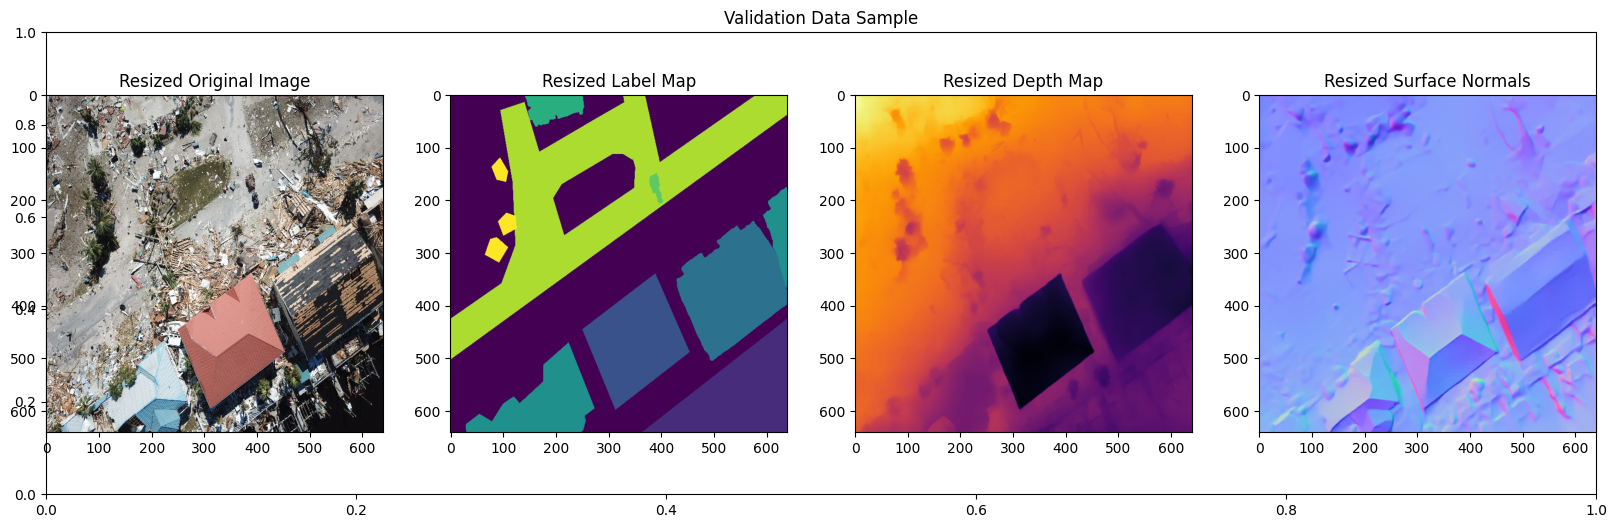

In [ ]:
img = cv2.imread('data/RescueNet/val/val-resized-img/10781.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
depth_img = cv2.imread('data/RescueNet/val/val-depthvis-img/10781_vis.png')
depth_img_rgb = cv2.cvtColor(depth_img, cv2.COLOR_BGR2RGB)
label_img = cv2.imread('data/RescueNet/val/val-label-img/10781_lab.png', cv2.IMREAD_GRAYSCALE)
resized_label_img = cv2.resize(label_img, (640, 640), cv2.INTER_NEAREST)
normal_img = cv2.imread('data/RescueNet/val/val-normalvis-img/10781_normal_vis.png')
normal_img_rgb = cv2.cvtColor(normal_img, cv2.COLOR_BGR2RGB)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
plt.title('Validation Data Sample')
plt.subplot(1, 4, 1)
plt.title('Resized Original Image')
plt.imshow(img_rgb)

plt.subplot(1, 4, 2)
plt.title('Resized Label Map')
plt.imshow(resized_label_img)

plt.subplot(1, 4, 3)
plt.title('Resized Depth Map')
plt.imshow(depth_img_rgb)

plt.subplot(1, 4, 4)
plt.title('Resized Surface Normals')
plt.imshow(normal_img_rgb)

plt.show()

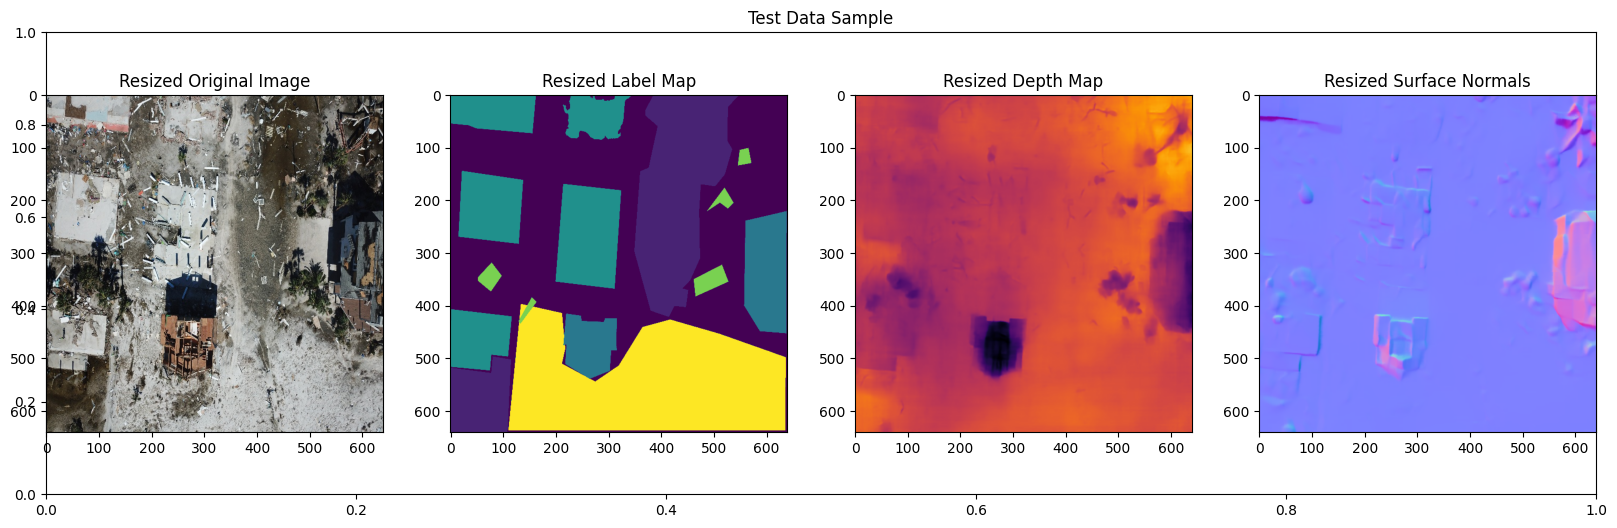

In [ ]:
img = cv2.imread('data/RescueNet/test/test-resized-img/10838.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
depth_img = cv2.imread('data/RescueNet/test/test-depthvis-img/10838_vis.png')
depth_img_rgb = cv2.cvtColor(depth_img, cv2.COLOR_BGR2RGB)
label_img = cv2.imread('data/RescueNet/test/test-label-img/10838_lab.png', cv2.IMREAD_GRAYSCALE)
resized_label_img = cv2.resize(label_img, (640, 640), cv2.INTER_NEAREST)
normal_img = cv2.imread('data/RescueNet/test/test-normalvis-img/10838_normal_vis.png')
normal_img_rgb = cv2.cvtColor(normal_img, cv2.COLOR_BGR2RGB)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
plt.title('Test Data Sample')
plt.subplot(1, 4, 1)
plt.title('Resized Original Image')
plt.imshow(img_rgb)

plt.subplot(1, 4, 2)
plt.title('Resized Label Map')
plt.imshow(resized_label_img)

plt.subplot(1, 4, 3)
plt.title('Resized Depth Map')
plt.imshow(depth_img_rgb)

plt.subplot(1, 4, 4)
plt.title('Resized Surface Normals')
plt.imshow(normal_img_rgb)

plt.show()